In [307]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

## Goal

#### The goal of this lab is to determine the charge-to-mass ratio ( e/m ) of the electron by analyzing its circular motion in a magnetic field generated by Helmholtz coils. 


## Procedure

* Fix a current \( I \) in the electron beam.
* Measure the diameter \( d \) of the resulting circular electron path.
* Plot the accelerating voltage \( V \) versus the square of the diameter \( d^2 \).
* Fit a linear regression line to estimate the slope, which corresponds to:

  $$
  \frac{e \cdot k^2 \cdot I^2}{8m}
  $$

* Divide the slope by $$ \frac{(k \cdot I)^2}{8} $$ to obtain an estimate for the charge-to-mass ratio $  \frac{e}{m} $.
* Repeat for a diffent current and then Compare the theoretical magnetic field with the magnetic field measured from the experimental data.


In [310]:
# Get the first data where fixed a current

data1 = pd.read_excel("data/data1.xlsx")
data1

,Current (A),Voltage (V),Diameter (cm),deltaD (cm),deltaV (V)
0,2.012,174,5.0,0.05,1.393
1,2.012,200,5.5,0.05,1.601
2,2.012,224,6.0,0.05,1.793
3,2.012,262,6.5,0.05,2.097
4,2.012,294,7.0,0.05,2.353
5,2.012,340,7.5,0.05,2.721
6,2.012,388,8.0,0.05,3.105
7,2.012,428,8.5,0.05,3.425
8,2.012,472,9.0,0.05,3.777
9,2.012,500,9.5,0.05,4.001


### Error Propagation for Squaring

For $ Q = A^2 $ with uncertainty $ \Delta A $, the propagated error is:

$$
\frac{\Delta Q}{Q} = 2 \cdot \frac{\Delta A}{A}
$$

$$
\Delta Q = Q \cdot 2 \cdot \frac{\Delta A}{A}
$$


In [312]:
sqr_uncertainty = lambda x, dx: 2 * abs(x) * (dx/x)


In [314]:
# convert the diameter measurments to meters
data1["Diameter (m)^2"] = (data1["Diameter (cm) "] * 1e-2) ** 2
data1["deltaD (m)^2"] = data1.apply(lambda col: sqr_uncertainty(col["Diameter (cm) "] * 1e-2, col["deltaD (cm)"] * 1e-2), axis=1)

data1

,Current (A),Voltage (V),Diameter (cm),deltaD (cm),deltaV (V),Diameter (m)^2,deltaD (m)^2
0,2.012,174,5.0,0.05,1.393,0.002500,0.001
1,2.012,200,5.5,0.05,1.601,0.003025,0.001
2,2.012,224,6.0,0.05,1.793,0.003600,0.001
3,2.012,262,6.5,0.05,2.097,0.004225,0.001
4,2.012,294,7.0,0.05,2.353,0.004900,0.001
5,2.012,340,7.5,0.05,2.721,0.005625,0.001
6,2.012,388,8.0,0.05,3.105,0.006400,0.001
7,2.012,428,8.5,0.05,3.425,0.007225,0.001
8,2.012,472,9.0,0.05,3.777,0.008100,0.001
9,2.012,500,9.5,0.05,4.001,0.009025,0.001


In [315]:
current_uncertainity = lambda x: 0.8e-2  * x + 0.001

In [317]:
current_1 = data1["Current (A)"][0]
d_current = current_uncertainity(current_1)

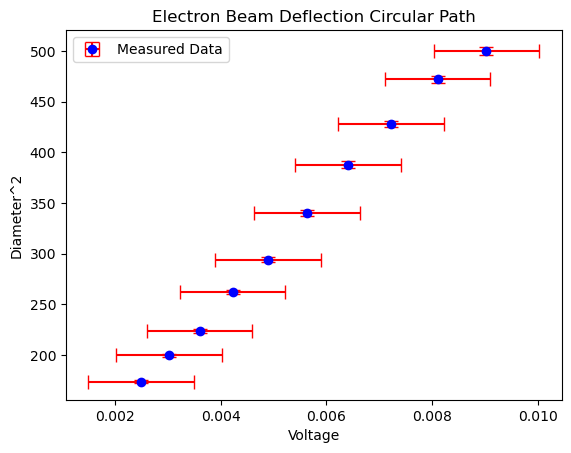

In [318]:
y = data1["Voltage (V) "]
x = data1["Diameter (m)^2"]
y_err = data1["deltaV (V)"]
x_err = data1["deltaD (m)^2"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Voltage")
plt.ylabel(r"Diameter^2")
plt.title("Electron Beam Deflection Circular Path")
plt.legend()
plt.show()


 Now we are going to fit a regression fit to get an estimate for 
  $$
  \frac{e \cdot k^2 \cdot I^2}{8m}
  $$

In [321]:
linear_model = lambda x, A, B: A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
d_slope, d_intercept = errors[0, 0], errors[1, 1]
print(f"{slope:.2e}, {intercept:.2e}")
d_slope, d_intercept

5.27e+04, 4.01e+01


(158815.60296897683, 3.1957044188576944)

$$
\text{Slope: } (5.2 \pm 1.5) \times 10^4 
$$
$$
\text{Intercept: } (4.0 \pm 0.3) \times 10^1
$$

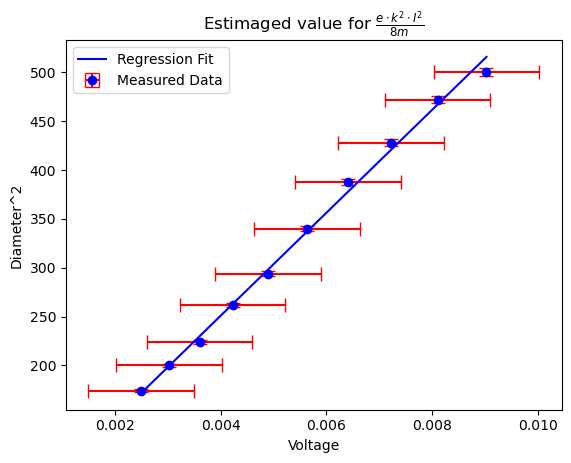

In [327]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Voltage")
plt.ylabel(r"Diameter^2")
plt.title(r"Estimaged value for $\frac{e \cdot k^2 \cdot I^2}{8m}$")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

## Dominant Source of Uncertainty

#### The dominant source of uncertainty in this experiment is the subjective estimation of the electron beam's circular path diameter by eye. Since the beam edge is often faint and not sharply defined, this can lead to inconsistent and potentially error-prone measurements.


### Error Propagation for $k$

Given the expression:

$$
k = \left( \frac{4}{5} \right)^{3/2} \cdot \frac{\mu_0 n}{R}
$$

Assuming $\mu_0$ is a constant and $n$ and $R$ have associated uncertainties $\Delta n$ and $\Delta R$, the relative uncertainty in $k$ is:

$$
\frac{\Delta k}{k} = \sqrt{
\left( \frac{\Delta n}{n} \right)^2 +
\left( \frac{\Delta R}{R} \right)^2
}
$$

Therefore, the absolute uncertainty in $k$ is:

$$
\Delta k = k \cdot \sqrt{
\left( \frac{\Delta n}{n} \right)^2 +
\left( \frac{\Delta R}{R} \right)^2
}
$$



In [330]:
# function for calculating the k value and its associated uncertainity 

k = lambda u, n, R: ((4/5)**(3/2)) * (( u * n ) / R)
k_uncertainity = lambda k, n, R, d_n, d_R: k * np.sqrt((d_n/n)**2 + (d_R/R)**2)

In [331]:
# Calculating the k value
u_o = 4 * np.pi * 1e-7;
n = 131 
d_n = 1
R = 16 * 1e-2
d_R = 1 * 1e-2

k1 = k(u_o, n, R)
d_k1 = k_uncertainity(k1, n, R, d_n, d_R)
print(f"{k1}, {d_k1}")

0.0007362005838130683, 4.6354463087950525e-05


### Value of \( k \) with Uncertainty

$$
k = (7.36 \pm 0.05) \times 10^{-4}
$$


#### To get the charge to mass ratio we are going to divide slope from our regression fit by  $$ \frac{(k \cdot I)^2}{8} $$


## Error propagation for charge to mass ratio

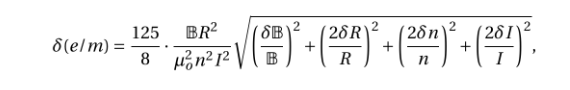

In [336]:
d_em = lambda B, d_B, u, R, d_R, n, d_n, I, d_I: (
    (125 / 8) * ((B * R**2) /  (u**2  * n**2 * I**2 )) *
    np.sqrt((d_B / B)**2 + (2 * d_R / R)**2 + (2 * d_n / n)**2 + (2 * d_I / I)**2)
)

In [337]:
# Calculating the charge to mass ratio and its associated error

charge_to_mass = (slope * 8) / (k1 * current_1)**2
d_charge_to_mass = d_em(slope, d_slope, u_o, R, d_R, n, d_n, current_1, d_current)
print(f"{charge_to_mass}, {d_charge_to_mass}")

192157756594.2507, 579589667611.2524


### Charge-to-Mass Ratio


$$
\frac{e}{m} = (2.0 \pm 0.6) * 10^{11} \ \text{C/kg}
$$


# Now we are going to repeat this experiment with a different current fixed

In [341]:
# Get the first data where current is fixed

data2 = pd.read_excel("data/data2.xlsx")
data2


,Current (A),Voltage (V),Diameter (cm),deltaD (cm),deltaV (V)
0,1.64,136,5.0,0.05,1.089
1,1.64,160,5.5,0.05,1.281
2,1.64,176,6.0,0.05,1.409
3,1.64,196,6.5,0.05,1.569
4,1.64,222,7.0,0.05,1.777
5,1.64,246,7.5,0.05,1.969
6,1.64,270,8.0,0.05,2.161
7,1.64,304,8.5,0.05,2.433
8,1.64,332,9.0,0.05,2.657
9,1.64,369,9.5,0.05,2.953


In [344]:
# Convert the diameter measurements to meters
data2["Diameter (m)^2"] = (data2["Diameter (cm)"] * 1e-2) ** 2
data2["deltaD (m)^2"] = data2.apply(lambda col: sqr_uncertainty(col["Diameter (cm)"] * 1e-2, col["deltaD (cm)"] * 1e-2), axis=1)

data2


,Current (A),Voltage (V),Diameter (cm),deltaD (cm),deltaV (V),Diameter (m)^2,deltaD (m)^2
0,1.64,136,5.0,0.05,1.089,0.002500,0.001
1,1.64,160,5.5,0.05,1.281,0.003025,0.001
2,1.64,176,6.0,0.05,1.409,0.003600,0.001
3,1.64,196,6.5,0.05,1.569,0.004225,0.001
4,1.64,222,7.0,0.05,1.777,0.004900,0.001
5,1.64,246,7.5,0.05,1.969,0.005625,0.001
6,1.64,270,8.0,0.05,2.161,0.006400,0.001
7,1.64,304,8.5,0.05,2.433,0.007225,0.001
8,1.64,332,9.0,0.05,2.657,0.008100,0.001
9,1.64,369,9.5,0.05,2.953,0.009025,0.001


In [345]:
current_2 = data2["Current (A)"][0]
d_current_2 = current_uncertainity(current_1)

## Visualizing the data

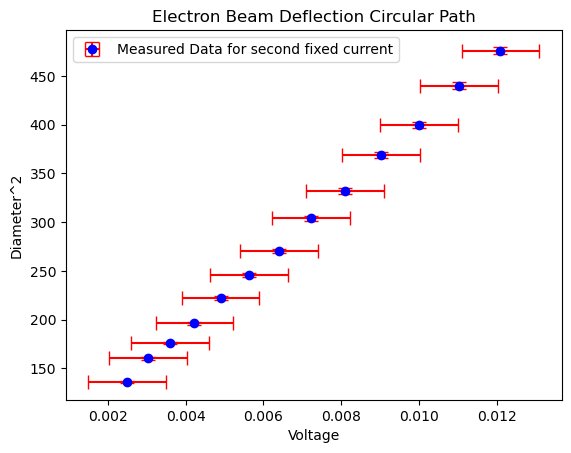

In [347]:
y = data2["Voltage (V)"]
x = data2["Diameter (m)^2"]
y_err = data2["deltaV (V)"]
x_err = data2["deltaD (m)^2"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data for second fixed current"
)

# Labels and title
plt.xlabel(r"Voltage")
plt.ylabel(r"Diameter^2")
plt.title("Electron Beam Deflection Circular Path")
plt.legend()
plt.show()


 Now we are going to fit a regression fit to get an estimate for 
  $$
  \frac{e \cdot k^2 \cdot I^2}{8m}
  $$

In [351]:
linear_model = lambda x, A, B: A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
d_slope, d_intercept = errors[0, 0], errors[1, 1]
print(f"{slope:.2e}, {intercept:.2e}")
d_slope, d_intercept

3.51e+04, 4.97e+01


(45565.15052110928, 1.2663467951896001)

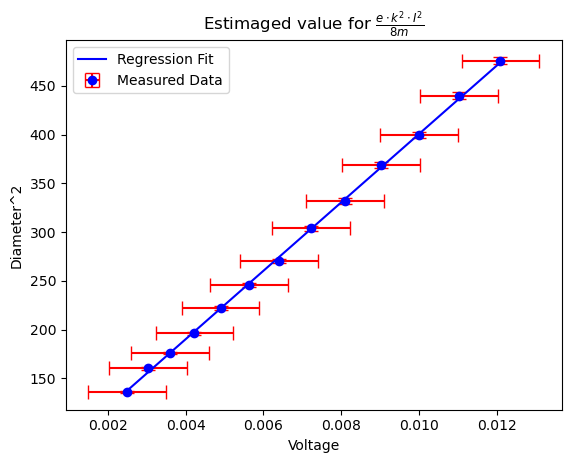

In [352]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Voltage")
plt.ylabel(r"Diameter^2")
plt.title(r"Estimaged value for $\frac{e \cdot k^2 \cdot I^2}{8m}$")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y = linear_model(line_space, slope, intercept)
plt.plot(line_space, y, label="Regression Fit", color='blue')

plt.legend(); 
plt.show()

In [353]:
# Calculating the charge to mass ratio and its associated error

charge_to_mass = (slope * 8) / (k1 * current_2)**2
d_charge_to_mass = d_em(slope, d_slope, u_o, R, d_R, n, d_n, current_2, d_current_2)
print(f"{charge_to_mass}, {d_charge_to_mass}")

192575610257.60812, 251264425155.25894


### Charge-to-Mass Ratio for second fixed current

$$
\frac{e}{m} = (2.0 \pm 0.3) * 10^{11} \ \text{C/kg}
$$


### We can see that as we increased the number of data measurements for different voltages, the values tended to remain consistent, but the uncertainty decreased.


## Comparison with Accepted Value

The accepted value for the charge-to-mass ratio of the electron is:

$$
\frac{e}{m} = (1.75882009 \pm 0.0000004) \times 10^{11} \ \text{C/kg}
$$

Our experimentally measured values are:

$$  (2.0 \pm 0.3) \times 10^{11} \ \text{C/kg} $$
$$ (2.0 \pm 0.6) \times 10^{11} \ \text{C/kg} $$

Since the accepted value lies within the uncertainty range of both measurements, our results are consistent with the accepted value and can be considered valid.


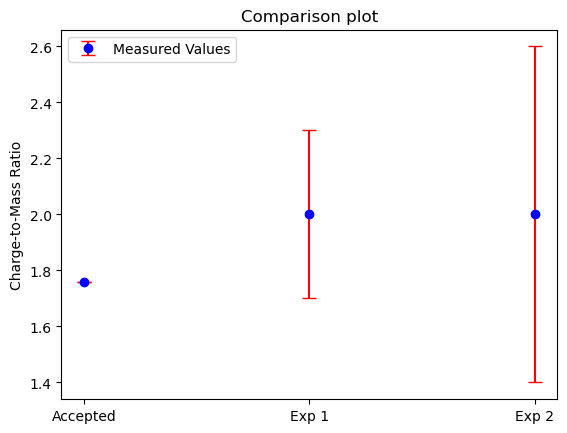

In [361]:
# Values
labels = ["Accepted", "Exp 1", "Exp 2"]
values = [1.75882009, 2.0, 2.0]
errors = [0.0000004, 0.3, 0.6]

# Scale all values to ×10^11 for readability
scale_factor = 1e11
scaled_values = [v for v in values]
scaled_errors = [e for e in errors]

# Plot
x = np.arange(len(labels))
plt.errorbar(x, scaled_values, yerr=scaled_errors, fmt='o', capsize=5, color='blue', ecolor='red', label="Measured Values")

plt.xticks(x, labels)
plt.ylabel("Charge-to-Mass Ratio")
plt.title("Comparison plot")
plt.legend()
plt.show()

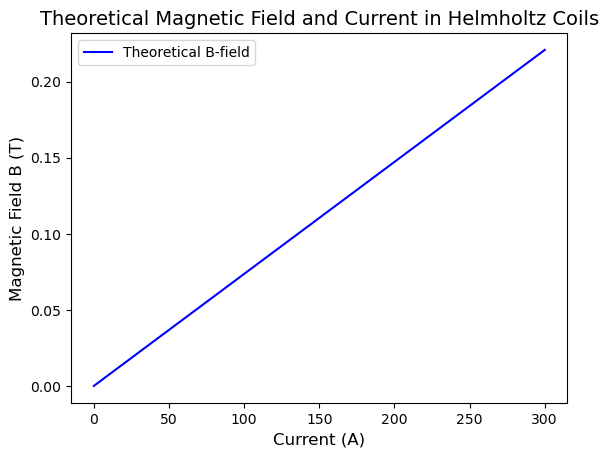

0.0007362005838130683


In [365]:
# Theoretical plot
B = lambda K, I: K * I

k_theory = k(u_o, n, R)
current = np.linspace(0, 300, 3000)

plt.plot(current, B(k_theory, current), label="Theoretical B-field", color="blue")

# Labels and title
plt.xlabel("Current (A)", fontsize=12)
plt.ylabel("Magnetic Field B (T)", fontsize=12)
plt.title("Theoretical Magnetic Field and Current in Helmholtz Coils", fontsize=14)

plt.legend()
plt.show()
print(k_theory)

In [366]:
data3 = pd.read_excel("data/data3.xlsx")

data3

,Field (B),Current (A)
0,0.8454,1.012
1,1.2657,1.520
2,1.7081,2.028
3,2.0862,2.473
4,2.4846,2.938


In [414]:
data3["d_Current (A)"] = data3["Current (A)"].apply(lambda row: current_uncertainity(row))
data3["d_Field (B)"] = data3["Field (B)"].apply(lambda row: current_uncertainity(row))

data3

,Field (B),Current (A),d_Current (A),d_Field (B)
0,0.8454,1.012,0.009096,0.007763
1,1.2657,1.520,0.013160,0.011126
2,1.7081,2.028,0.017224,0.014665
3,2.0862,2.473,0.020784,0.017690
4,2.4846,2.938,0.024504,0.020877


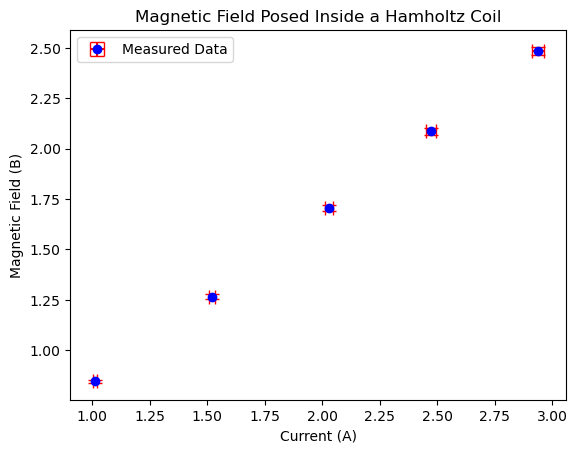

In [416]:
y = data3["Field (B)"]
x = data3["Current (A)"]
y_err = data3["d_Field (B)"]
x_err = data3["d_Current (A)"]

# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel(r"Magnetic Field (B)")
plt.title("Magnetic Field Posed Inside a Hamholtz Coil")
plt.legend()
plt.show()

In [417]:
linear_model = lambda x, A, B: A * x + B

# having a best fit line
parameters, errors = curve_fit( linear_model, x, y, sigma = y_err, absolute_sigma=True )

slope = parameters[0]
intercept = parameters[1]
d_slope, d_intercept = errors[0, 0], errors[1, 1]
print(f"{slope:.2e}, {intercept:.2e}")
d_slope, d_intercept

8.50e-01, -1.78e-02


(7.69455703167788e-05, 0.00020806349774983408)

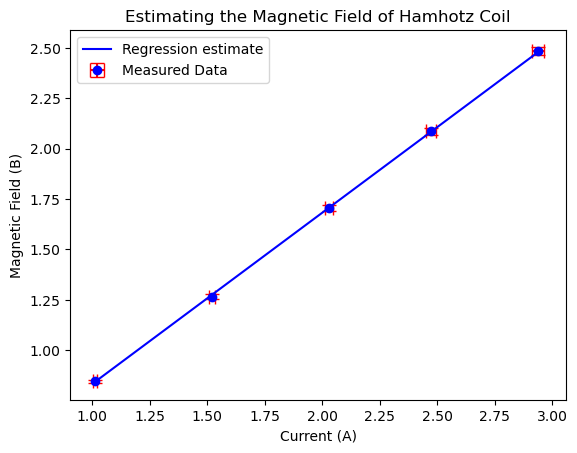

In [418]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Magnetic Field (B)")
plt.title("Estimating the Magnetic Field of Hamhotz Coil")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y_ = linear_model(line_space, slope, intercept)
plt.plot(line_space, y_, label="Regression estimate", color='blue')



plt.legend(); 
plt.show()

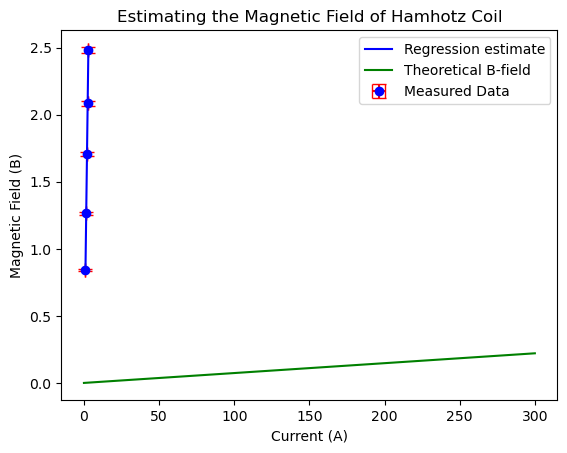

In [419]:
# Plot with error bars
plt.errorbar(
    x, y, 
    xerr=x_err, yerr=y_err, 
    fmt="o", capsize=5, markersize=6, 
    color="blue", ecolor="red", 
    label="Measured Data"
)

# Labels and title
plt.xlabel(r"Current (A)")
plt.ylabel("Magnetic Field (B)")
plt.title("Estimating the Magnetic Field of Hamhotz Coil")


# plotting the regression fit
line_space = np.linspace(min(x), max(x), 1000)
y_ = linear_model(line_space, slope, intercept)
plt.plot(line_space, y_, label="Regression estimate", color='blue')

plt.plot(current, B(k_theory, current), label="Theoretical B-field", color="green")

plt.legend(); 
plt.show()

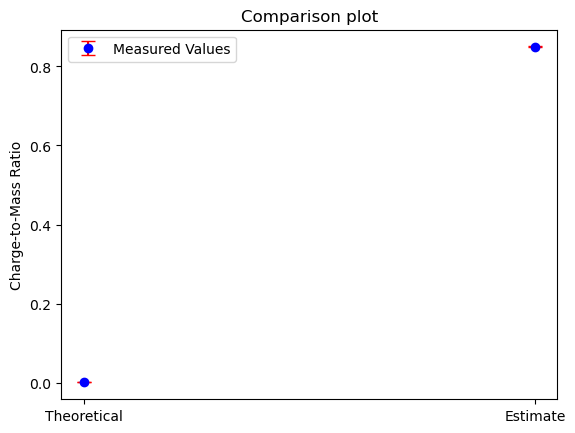

In [420]:
# Values
labels = ["Theoretical", "Estimate"]
values = [k_theory, slope]
errors = [0, d_slope]

# Scale all values to ×10^11 for readability
scaled_values = [v for v in values]
scaled_errors = [e for e in errors]

# Plot
x = np.arange(len(labels))
plt.errorbar(x, scaled_values, yerr=scaled_errors, fmt='o', capsize=5, color='blue', ecolor='red', label="Measured Values")

plt.xticks(x, labels)
plt.ylabel("Charge-to-Mass Ratio")
plt.title("Comparison plot")
plt.legend()
plt.show()

## Connection to physics



In this lab, we analyzed the circular motion of electrons in a magnetic field generated by Helmholtz coils to experimentally determine the electron's charge-to-mass ratio $\frac{e}{m} $. Our measurements demonstrated that electrons follow circular trajectories when subjected to a magnetic field, a phenomenon described by the Lorentz force equation:

$$
\vec{F} = q(\vec{v} \times \vec{B})
$$

Due to the electron's extremely small mass compared to its relatively large charge, even a modest magnetic field produced a significant deflection of the electron beam. This observation emphasizes the inherently large magnitude of the electron's \( \frac{e}{m} \) ratio, highlighting the electron's characteristic as a particle possessing a disproportionately large charge relative to its very small mass. Our experimental findings closely match the accepted value, reinforcing the theoretical principles of electromagnetism and particle physics.


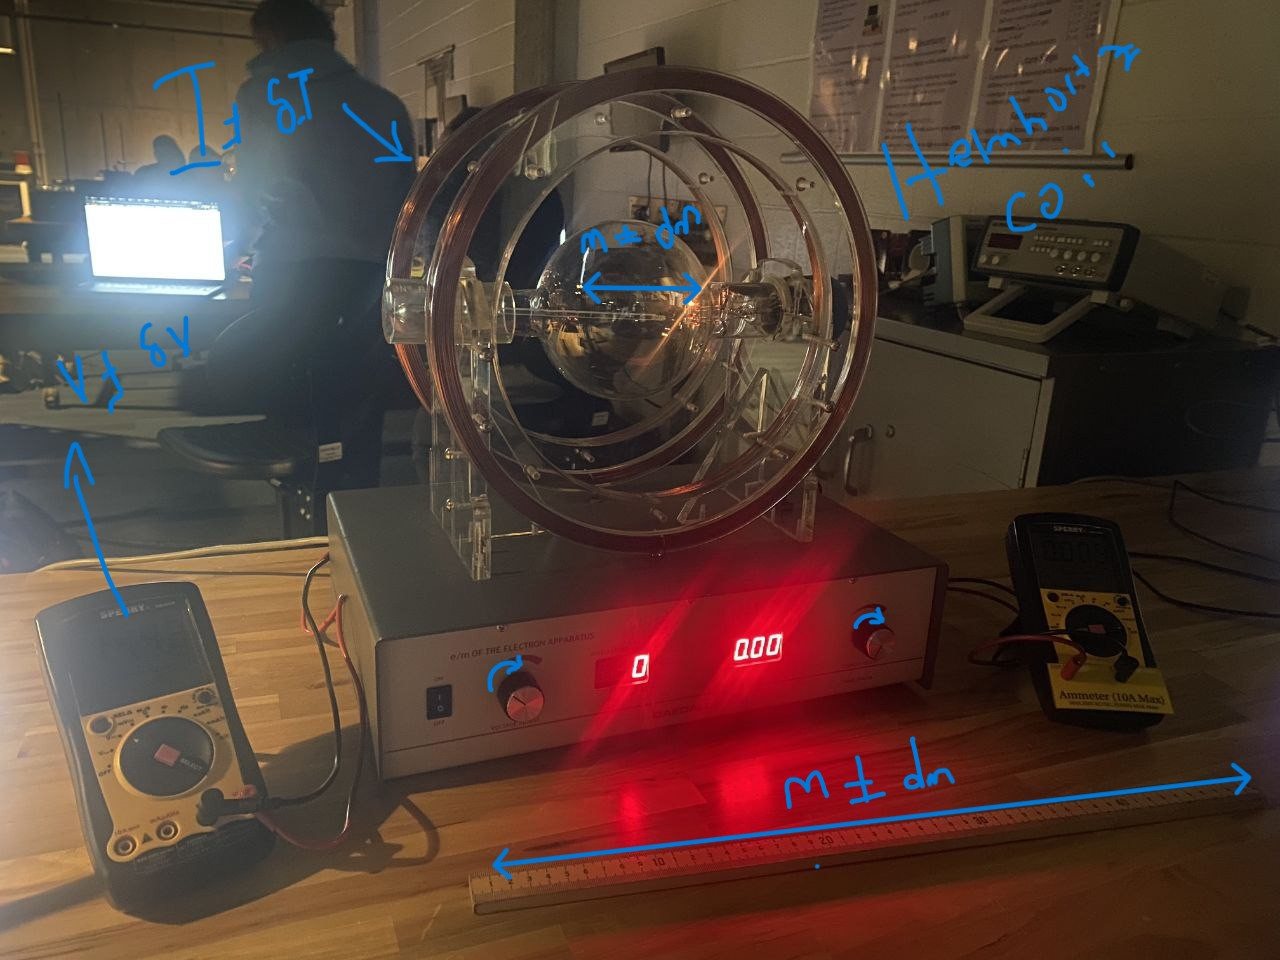